<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/GenderPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd
import re
import gdown
google_drive_link = "https://drive.google.com/file/d/1wfpbNWY4S39u5GuNxBr218N_gyXmCEUv/view?usp=drive_link"
file_id = re.search(r"/d/(\w+)/", google_drive_link).group(1)
# Define the output file name
output_file = 'genderprediction.csv'
# Download the file
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_file, quiet=False)
# Load the dataset into a Pandas DataFrame
data = pd.read_csv(output_file)

Downloading...
From (original): https://drive.google.com/uc?id=1wfpbNWY4S39u5GuNxBr218N_gyXmCEUv
From (redirected): https://drive.google.com/uc?id=1wfpbNWY4S39u5GuNxBr218N_gyXmCEUv&confirm=t&uuid=4106ba93-b873-4845-a0aa-78a8be994a2d
To: /content/genderprediction.csv
100%|██████████| 200M/200M [00:02<00:00, 72.1MB/s]


In [3]:
data.head()

,age,ethnicity,gender,img_name,pixels
0,1,2,0,20161219203650636.jpg.chip.jpg,129 128 128 126 127 130 133 135 139 142 145 14...
1,1,2,0,20161219222752047.jpg.chip.jpg,164 74 111 168 169 171 175 182 184 188 193 199...
2,1,2,0,20161219222832191.jpg.chip.jpg,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,1,2,0,20161220144911423.jpg.chip.jpg,193 197 198 200 199 200 202 203 204 205 208 21...
4,1,2,0,20161220144914327.jpg.chip.jpg,202 205 209 210 209 209 210 211 212 214 218 21...


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23705 entries, 0 to 23704
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        23705 non-null  int64 
 1   ethnicity  23705 non-null  int64 
 2   gender     23705 non-null  int64 
 3   img_name   23705 non-null  object
 4   pixels     23705 non-null  object
dtypes: int64(3), object(2)
memory usage: 926.1+ KB


In [5]:
data["gender"].value_counts()

,count
gender,
0,12391
1,11314


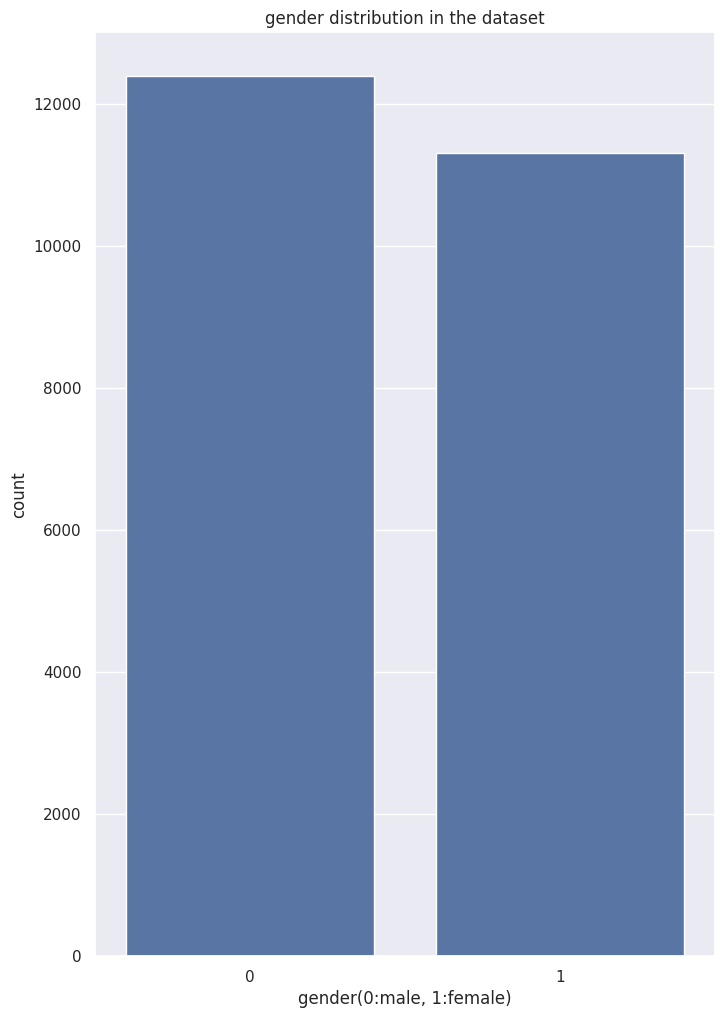

In [6]:
plt.figure(figsize = (8, 12))
sns.countplot(data = data, x = "gender")
plt.xlabel("gender(0:male, 1:female)")
plt.ylabel("count")
plt.title("gender distribution in the dataset")
plt.show()

In [7]:
import numpy as np
# Map the 'pixels' column by splitting the space-separated string, converting to float32, and reshaping into 48x48 arrays
data['pixels'] = data['pixels'].map(lambda x: np.array(x.split(' '), dtype=np.float32).reshape(48, 48))


### feature and target

In [8]:
#extract pixel data from the dataframe and convert it to a numpy array
images = np.array(data["pixels"].to_list())

#extract the "gender" column values as labels
labels = data["gender"].values

### data transformation

# Reshape the array to have a 4D shape (number of samples, width, height, number of channels)
# In this case, the images are grayscale, so the number of channels is 1

In [9]:
images_reshaped = images.reshape(images.shape[0], 48, 48, 1)

### data normalization

# Check if the maximum pixel value in the images array is greater than 1

In [10]:
if np.max(images_reshaped)>1:
  #Normalize the pixel values by dividing by 255
  images_reshaped = images_reshaped / 255

###Data Splitting

In [11]:
from sklearn.model_selection import train_test_split

#split the data into training and testing sets
train_images, test_images, train_labels, test_labels = train_test_split(images_reshaped, labels, test_size = 0.2, random_state = 42)

In [12]:
#further split and testing set into testing and validation sets
test_images, val_images, test_labels, val_labels = train_test_split(test_images, test_labels, test_size = 0.5, random_state = 42)

In [13]:
#print the sizes of the resulting sets
print(f"Training set size : {train_images.shape[0]} samples")
print(f"Validation set size : {val_images.shape[0]} samples")
print(f"Testing set size : {test_images.shape[0]} samples")

Training set size : 18964 samples
Validation set size : 2371 samples
Testing set size : 2370 samples


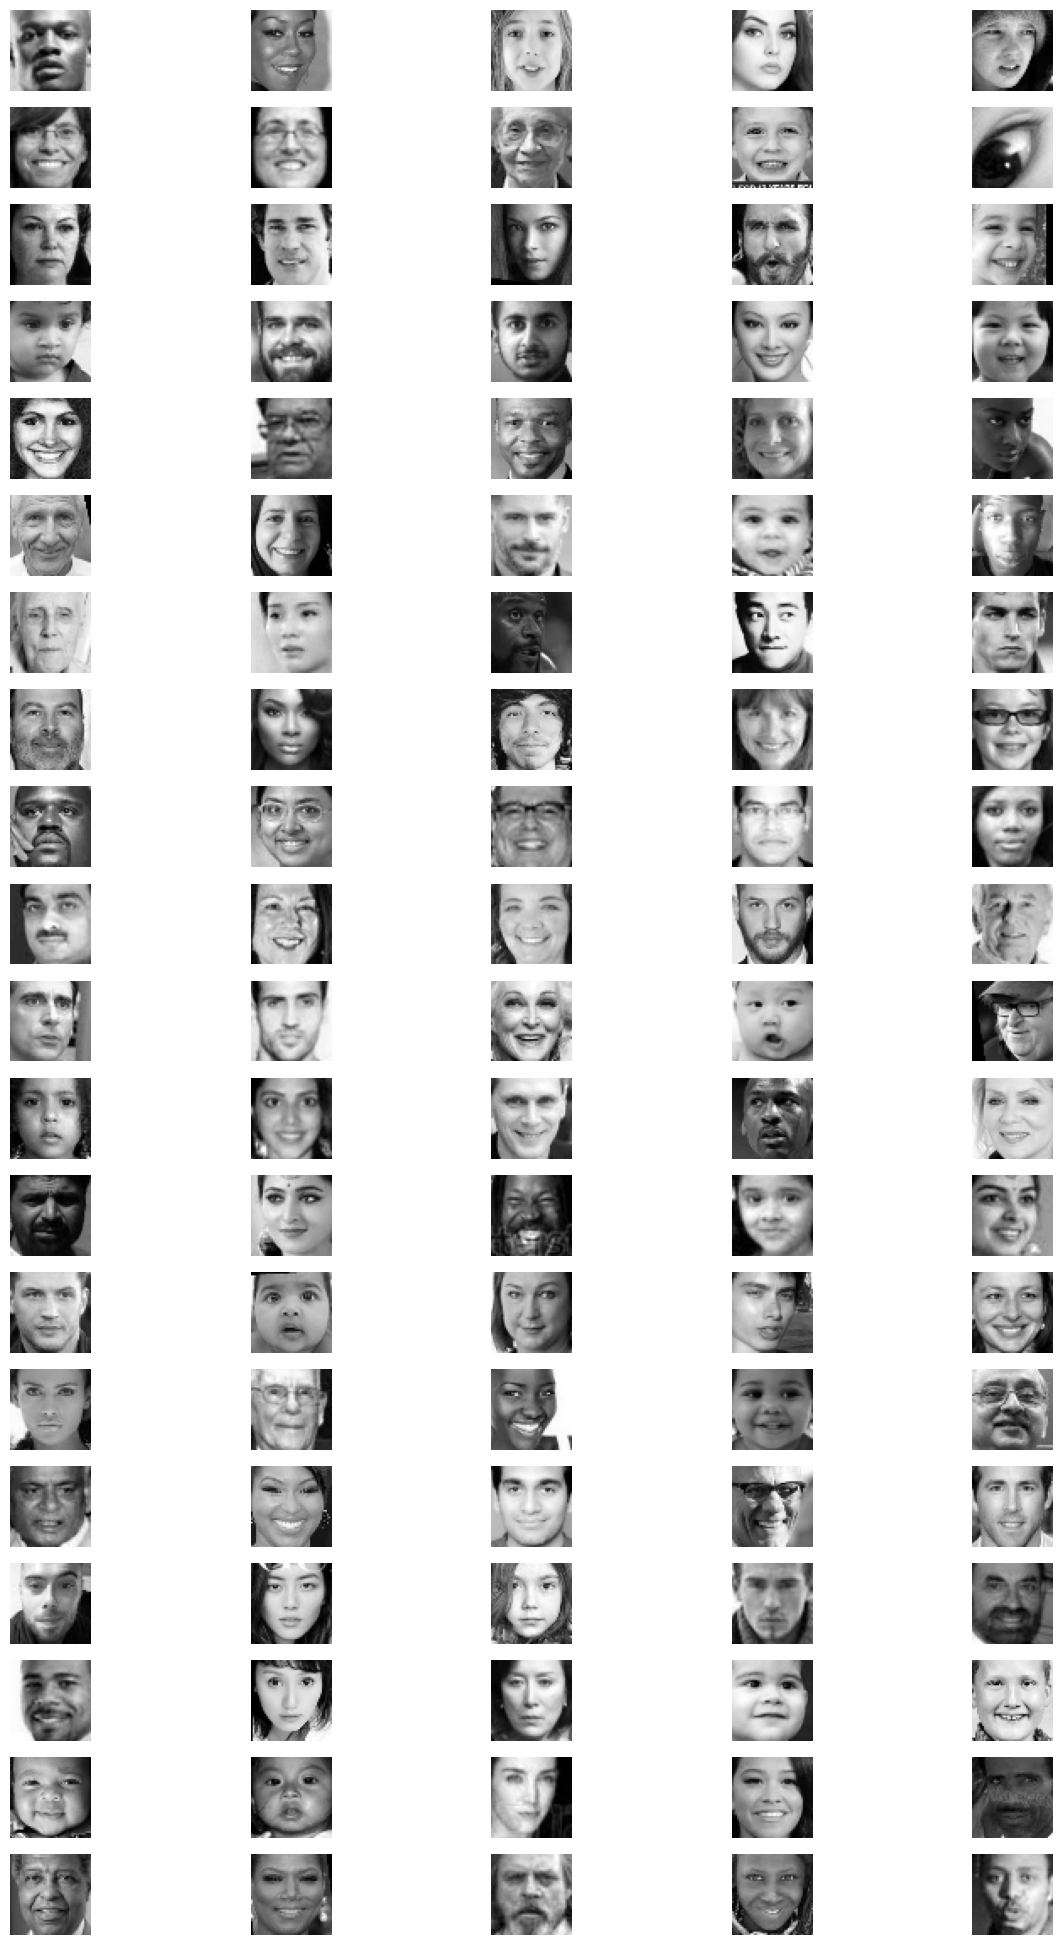

In [16]:
#plot 100 random grayscale images
fig, axes = plt.subplots(20, 5, figsize = (15, 25))

for row in range(20):
  for col in range(5):
    random_face = np.random.choice(len(data))
    image = data["pixels"][random_face]

    axes[row, col].imshow(image, cmap = "gray")
    axes[row, col].axis("off")

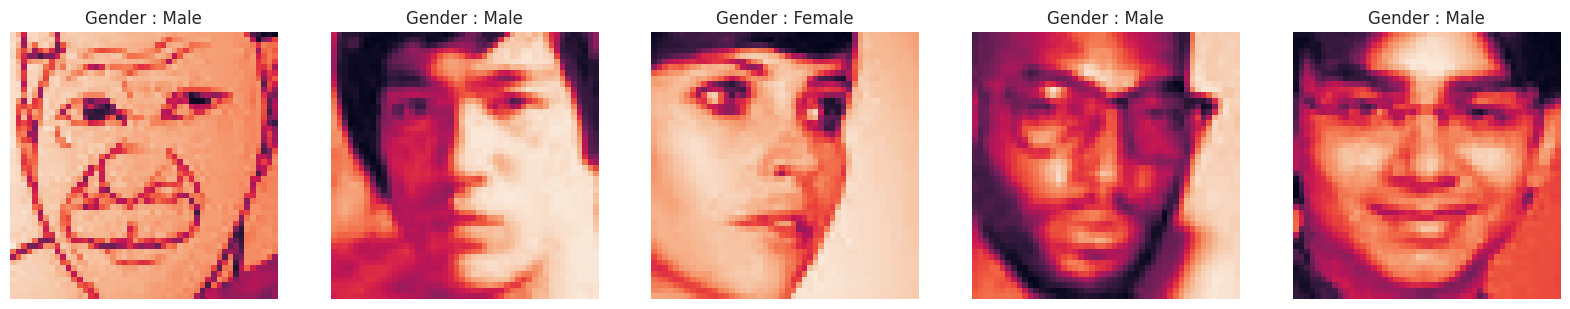

In [19]:
#plot some pics
fig, axes = plt.subplots(1, 5, figsize = (20, 10))

#randomly select and display 5 faces with their gender labels
for i in range(5):
  random_face = np.random.choice(len(data))

  gender = data["gender"][random_face]

  axes[i].set_title("Gender : {}".format("Female" if gender else "Male"))
  axes[i].imshow(data["pixels"][random_face])
  axes[i].axis("off")

### define variables

In [21]:
input_shape = train_images.shape[1:] # define the input shape for the neural netwrok (shape of each image).
n_epochs = 25 # define the num. of training epochs,
batch_size = 64 #set the batch size for training

### model architecture